# Day 5 - Free-Space Path Loss Plot 

In this Notebook, I will calculate and plot free-space path loss as a function of satellite range. +

The goal is to understand how path loss changes with distance and carrier frequency is satellite communication systems.

## Free-Space Path Loss Theory

Free-space path loss describes how much signal power is lost as an electromagnetic wave propagates through space.

The equation is:

$$
L_{FS}=20\log_{10}\left(\frac{4\pi R f}{c}\right)
$$

where:

- $(L_{FS}$) is free-space path loss in dB
- \(R\) is the distance between transmitter and receiver in meters
- \(f\) is the carrier frequency in Hz
- \(c\) is the speed of light in m/s

In satellite communication, this value is usually very large because the distance between satellite and ground station can be hundreds, thousands, or tens of thousands of kilometers.

In [21]:
import numpy as np # calculate FSPL for many range values at once
import matplotlib.pyplot as plt # plotting library
from pathlib import Path # helps to create folders and file paths cleanly, better than hardcoding paths everywhere

In [22]:
SPEED_OF_LIGHT_M_PER_S = 299_792_458

def calculate_fspl_db(range_m, frequency_hz):
    """
    Calculate free-space path loss 
    
    Parameters
    ----------
    range_m: float or numpy array
        Distance between transmitter and receiver in meters 
    
    frequency_hz: float
        Carrier frequency in Hz.
    
    Returns
    ----------
    float or numpy array
        Free-space path loss in dB.
    """
    fspl_db = 20 * np.log10((4 * np.pi * range_m * frequency_hz) / SPEED_OF_LIGHT_M_PER_S)

    return fspl_db

In [23]:
ranges_km = np.linspace(500, 40_000, 500) # create 500 range values between, LEO hunders to a few thousand km;MEO ~ several thousand to ~20000km ;GEO like ranges 35,786 km altitude
ranges_m = ranges_km * 1000

carrier_frequency_hz = {"S-band, 2.2 GHz": 2.2e9, "X-band, 9.5 GHz":8.4e9, "Ku-band, 12 GHz":12.0e9, "Ka-band, 26.5 GHz":26.5e9,}

In [24]:
example_ranges_km = [500, 1000, 2000, 35_786]

print("Free-Space Path Loss Examples")
print("-----------------------------")

for band_name, frequency_hz in carrier_frequency_hz.items():
    print()
    print(band_name)

    for range_km in example_ranges_km:
        range_m = range_km * 1000
        fspl_db = calculate_fspl_db(range_m, frequency_hz)

        print(f"Range: {range_km:8.0f} km | FSPL: {fspl_db:8.2f} dB")

Free-Space Path Loss Examples
-----------------------------

S-band, 2.2 GHz
Range:      500 km | FSPL:   153.28 dB
Range:     1000 km | FSPL:   159.30 dB
Range:     2000 km | FSPL:   165.32 dB
Range:    35786 km | FSPL:   190.37 dB

X-band, 9.5 GHz
Range:      500 km | FSPL:   164.91 dB
Range:     1000 km | FSPL:   170.93 dB
Range:     2000 km | FSPL:   176.95 dB
Range:    35786 km | FSPL:   202.01 dB

Ku-band, 12 GHz
Range:      500 km | FSPL:   168.01 dB
Range:     1000 km | FSPL:   174.03 dB
Range:     2000 km | FSPL:   180.05 dB
Range:    35786 km | FSPL:   205.11 dB

Ka-band, 26.5 GHz
Range:      500 km | FSPL:   174.89 dB
Range:     1000 km | FSPL:   180.91 dB
Range:     2000 km | FSPL:   186.93 dB
Range:    35786 km | FSPL:   211.99 dB


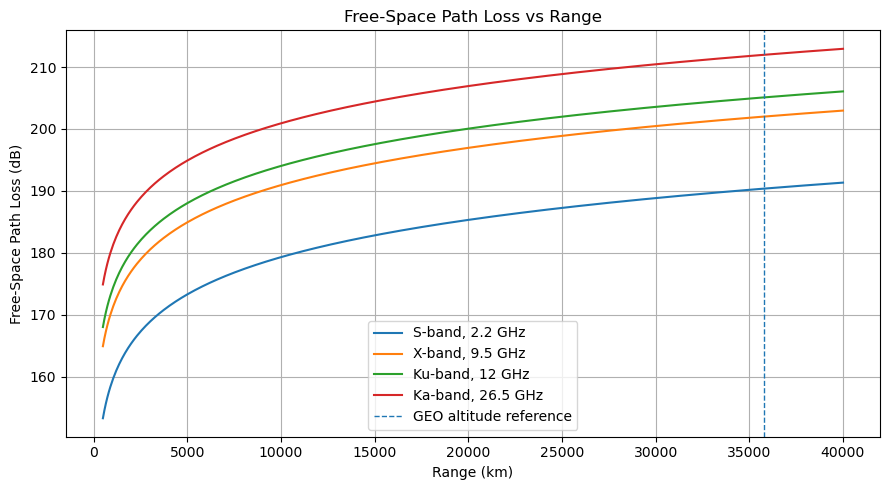

Saved plot to: 00_python_satcom_warmup\day05_fspl_vs_range.png


In [25]:
plt.figure(figsize=(9,5))

for band_name, frequency_hz in carrier_frequency_hz.items():
    fspl_db = calculate_fspl_db(ranges_m, frequency_hz)

    plt.plot(ranges_km, fspl_db, label=band_name)

plt.axvline(35_786, linestyle = "--", linewidth = 1, label = "GEO altitude reference")

plt.title("Free-Space Path Loss vs Range")
plt.xlabel("Range (km)")
plt.ylabel("Free-Space Path Loss (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = Path("00_python_satcom_warmup/day05_fspl_vs_range.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved plot to: {output_path}")

## Engineering Interpretation

The plot shows two important SatCom effects.

First, free-space path loss increases as range increases. This means that a satellite farther from the ground station produces a weaker received signal if all other parameters stay constant.

Second, free-space path loss increases as carrier frequency increases. For the same range, Ka-band has more free-space path loss than Ku-band, X-band, or S-band.

This does not mean higher frequencies are bad. Higher frequencies can provide more bandwidth and allow smaller antennas, but they also require careful link-budget design.

A useful rule:

- Doubling range increases FSPL by about 6 dB.
- Doubling frequency also increases FSPL by about 6 dB.